In [1]:
import pandas as pd

df = pd.read_csv("online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1067371
Columns : 8


In [4]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 34335


In [7]:
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print(df.shape)

(797885, 8)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

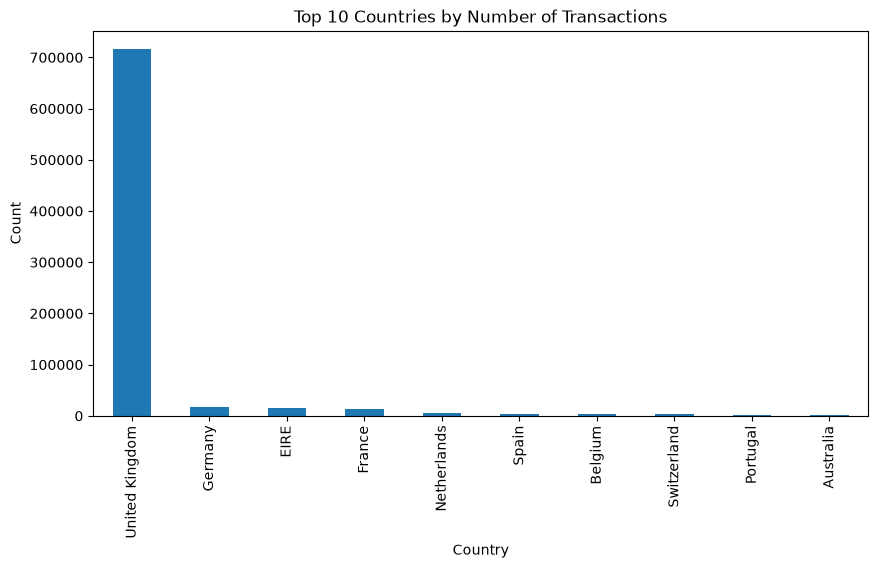

In [9]:
plt.figure(figsize=(10,5))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

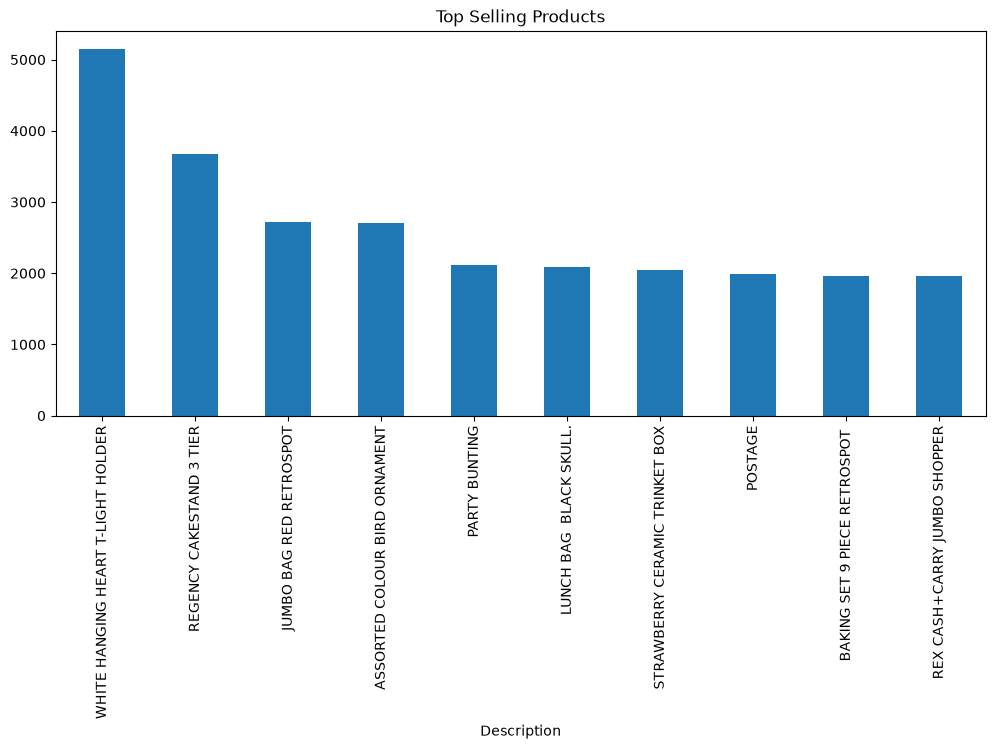

In [10]:
plt.figure(figsize=(12,5))

df["Description"].value_counts().head(10).plot(kind="bar")

plt.title("Top Selling Products")

plt.show()

In [11]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [12]:
customer = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Quantity": "sum",
    "TotalAmount": "sum"
})

customer.columns = [
    "TotalInvoices",
    "TotalQuantity",
    "TotalSpent"
]

customer.head()

,TotalInvoices,TotalQuantity,TotalSpent
Customer ID,,,
12346.0,17,53,-51.74
12347.0,8,2967,4921.53
12348.0,5,2714,2019.40
12349.0,5,1619,4404.54
12350.0,1,197,334.40


In [13]:
customer.describe()

,TotalInvoices,TotalQuantity,TotalSpent
count,5942.000000,5942.000000,5942.000000
mean,7.552339,1692.313867,2741.499712
std,15.972262,8486.732648,13676.639629
min,1.000000,-1085.000000,-25111.090000
25%,2.000000,176.250000,321.065000
50%,4.000000,461.500000,822.010000
75%,8.000000,1310.250000,2142.195000
max,510.000000,365220.000000,570380.610000


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer)

In [16]:
from sklearn.cluster import KMeans

In [17]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

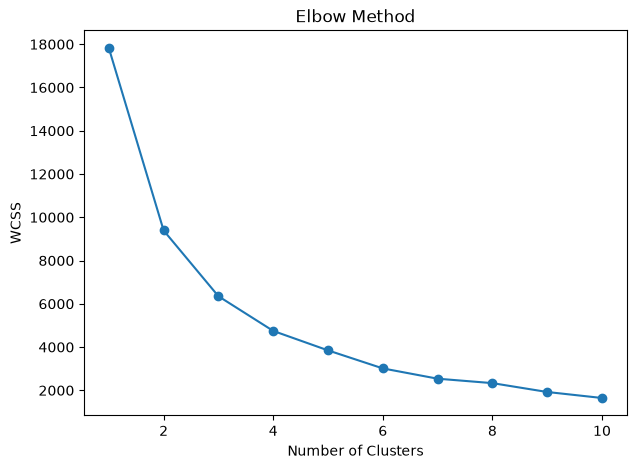

In [18]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [19]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer["Cluster"] = kmeans.fit_predict(scaled_data)

customer.head()

,TotalInvoices,TotalQuantity,TotalSpent,Cluster
Customer ID,,,,
12346.0,17,53,-51.74,1
12347.0,8,2967,4921.53,1
12348.0,5,2714,2019.40,1
12349.0,5,1619,4404.54,1
12350.0,1,197,334.40,1


In [20]:
customer["Cluster"].value_counts()

Cluster
1    5564
0     357
2      19
3       2
Name: count, dtype: int64

In [21]:
customer.groupby("Cluster").mean()

,TotalInvoices,TotalQuantity,TotalSpent
Cluster,,,
0,38.128852,8951.464986,14609.154216
1,4.966391,830.775701,1368.378467
2,174.421053,89051.842105,124586.461053
3,158.500000,272817.500000,546861.340000


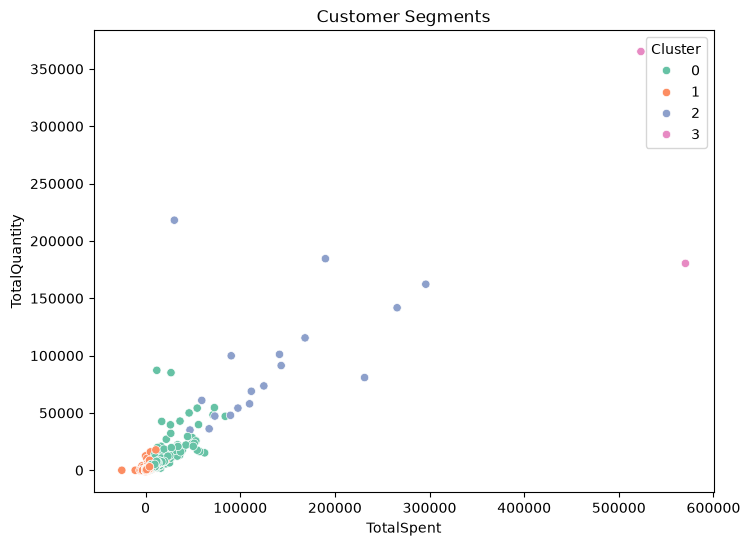

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer,
    x="TotalSpent",
    y="TotalQuantity",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

In [23]:
customer.groupby("Cluster").agg({
    "TotalInvoices":"mean",
    "TotalQuantity":"mean",
    "TotalSpent":"mean"
})

,TotalInvoices,TotalQuantity,TotalSpent
Cluster,,,
0,38.128852,8951.464986,14609.154216
1,4.966391,830.775701,1368.378467
2,174.421053,89051.842105,124586.461053
3,158.500000,272817.500000,546861.340000


Business Recommendations

• Cluster 0:
Customers spend less and purchase infrequently.
Recommendation: Offer discounts and promotional campaigns to increase engagement.

• Cluster 1:
High-value customers with frequent purchases.
Recommendation: Introduce loyalty programs and exclusive offers to retain them.

• Cluster 2:
Customers with moderate spending habits.
Recommendation: Recommend complementary products through personalized marketing.

• Cluster 3:
Customers who purchase in large quantities.
Recommendation: Provide bulk purchase discounts and premium membership benefits.